<a href="https://colab.research.google.com/github/sravyamannam09-tech/Movie-recommended-mini-system-/blob/main/MOVIE_RECOMMENDED_MINI_SYSTEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 2)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
TOP_K = 2

# Maximum number of SVD iterations
MAX_ITERATIONS = 100

# Convergence tolerance
TOLERANCE = 1e-4

# --------------------------------------------
# Movie names
# --------------------------------------------

movies = [
    "Interstellar",
    "Avengers",
    "Toy Story",
    "Inception",
    "Titanic",
    "The Matrix",
    "Frozen",
    "Jurassic Park"
]

# --------------------------------------------
# User names
# --------------------------------------------

users = [
    "User 1",
    "User 2",
    "User 3",
    "User 4",
    "User 5"
]

# --------------------------------------------
# Rating matrix
#
# 0 = missing/unrated
#
# Rows    -> Users
# Columns -> Movies
# --------------------------------------------

R = np.array([
    [5, 4, 0, 5, 0, 4, 0, 0],  # User 1
    [4, 0, 5, 4, 0, 5, 0, 0],  # User 2
    [0, 5, 4, 0, 5, 0, 4, 0],  # User 3
    [0, 0, 5, 0, 4, 5, 0, 4],  # User 4
    [0, 4, 0, 0, 5, 0, 5, 4]   # User 5
], dtype=float)

# Basic validation
assert R.shape == (5, 8), "The matrix must contain 5 users and 8 movies."
assert TOP_K <= min(R.shape), "TOP_K is too large."

print("Project configuration loaded successfully.")
print(f"Users  : {len(users)}")
print(f"Movies : {len(movies)}")
print(f"Matrix : {R.shape}")
print(f"Rank k : {TOP_K}")

Project configuration loaded successfully.
Users  : 5
Movies : 8
Matrix : (5, 8)
Rank k : 2


In [3]:
rating_table = pd.DataFrame(
    R,
    index=users,
    columns=movies
)

print("Original Rating Matrix R")
print("0 means the movie has not been rated.\n")

display(rating_table)

Original Rating Matrix R
0 means the movie has not been rated.



,Interstellar,Avengers,Toy Story,Inception,Titanic,The Matrix,Frozen,Jurassic Park
User 1,5.0,4.0,0.0,5.0,0.0,4.0,0.0,0.0
User 2,4.0,0.0,5.0,4.0,0.0,5.0,0.0,0.0
User 3,0.0,5.0,4.0,0.0,5.0,0.0,4.0,0.0
User 4,0.0,0.0,5.0,0.0,4.0,5.0,0.0,4.0
User 5,0.0,4.0,0.0,0.0,5.0,0.0,5.0,4.0


In [4]:
missing_mask = (R == 0)

number_of_ratings = np.sum(~missing_mask)
number_of_missing = np.sum(missing_mask)

print("Number of known ratings   :", number_of_ratings)
print("Number of missing ratings :", number_of_missing)

print(
    f"Matrix sparsity = "
    f"{number_of_missing / R.size * 100:.1f}%"
)

Number of known ratings   : 20
Number of missing ratings : 20
Matrix sparsity = 50.0%


In [5]:
R_filled = R.copy()

for i in range(R.shape[0]):

    # Find ratings that are not missing
    known_ratings = R[i][R[i] > 0]

    # Calculate that user's average rating
    user_mean = np.mean(known_ratings)

    # Replace missing values with the user's mean
    R_filled[i][missing_mask[i]] = user_mean

print("Initial matrix after mean initialization:\n")

initial_table = pd.DataFrame(
    R_filled,
    index=users,
    columns=movies
)

display(initial_table)

Initial matrix after mean initialization:



,Interstellar,Avengers,Toy Story,Inception,Titanic,The Matrix,Frozen,Jurassic Park
User 1,5.0,4.0,4.5,5.0,4.5,4.0,4.5,4.5
User 2,4.0,4.5,5.0,4.0,4.5,5.0,4.5,4.5
User 3,4.5,5.0,4.0,4.5,5.0,4.5,4.0,4.5
User 4,4.5,4.5,5.0,4.5,4.0,5.0,4.5,4.0
User 5,4.5,4.0,4.5,4.5,5.0,4.5,5.0,4.0


In [6]:
def rank_k_svd(matrix, k):
    """
    Perform Singular Value Decomposition and
    reconstruct the matrix using only the
    largest k singular values.
    """

    # SVD:
    # matrix = U @ S @ Vt
    U, singular_values, Vt = np.linalg.svd(
        matrix,
        full_matrices=False
    )

    # Keep only the first k components
    U_k = U[:, :k]
    S_k = singular_values[:k]
    Vt_k = Vt[:k, :]

    # Convert singular values into a diagonal matrix
    Sigma_k = np.diag(S_k)

    # Low-rank approximation:
    # R_k = U_k Sigma_k V_k^T
    reconstructed = U_k @ Sigma_k @ Vt_k

    return U, singular_values, Vt, reconstructed


# Run one SVD
U, singular_values, Vt, R_rank2 = rank_k_svd(
    R_filled,
    TOP_K
)

print("Singular values:")
print(singular_values)

print("\nTop-2 singular values:")
print(singular_values[:TOP_K])

print("\nRank-2 approximation:")
display(
    pd.DataFrame(
        R_rank2,
        index=users,
        columns=movies
    )
)

Singular values:
[28.468  1.438  1.222  0.873  0.527]

Top-2 singular values:
[28.468  1.438]

Rank-2 approximation:


,Interstellar,Avengers,Toy Story,Inception,Titanic,The Matrix,Frozen,Jurassic Park
User 1,4.85,4.25,4.21,4.85,4.86,4.11,4.47,4.38
User 2,4.15,4.55,4.98,4.15,4.34,5.08,4.52,4.22
User 3,4.65,4.33,4.43,4.65,4.71,4.38,4.49,4.33
User 4,4.24,4.51,4.89,4.24,4.41,4.96,4.52,4.24
User 5,4.61,4.36,4.49,4.61,4.68,4.46,4.50,4.33


In [7]:
def complete_matrix_with_svd(
    original_matrix,
    k=2,
    max_iterations=100,
    tolerance=1e-4
):
    """
    Complete missing ratings using iterative
    rank-k SVD approximation.

    Known ratings remain fixed.
    Missing ratings are estimated.
    """

    # 0 indicates missing data
    missing = (original_matrix == 0)

    # Start with the original matrix
    completed = original_matrix.astype(float).copy()

    # Initial mean filling
    for i in range(completed.shape[0]):

        known = original_matrix[i][original_matrix[i] > 0]

        if len(known) > 0:
            mean_rating = np.mean(known)
            completed[i][missing[i]] = mean_rating

    previous = completed.copy()

    for iteration in range(max_iterations):

        # ------------------------------------
        # SVD
        # ------------------------------------

        U, S, Vt = np.linalg.svd(
            completed,
            full_matrices=False
        )

        # ------------------------------------
        # Keep top-k singular values
        # ------------------------------------

        U_k = U[:, :k]
        S_k = S[:k]
        Vt_k = Vt[:k, :]

        # Rank-k approximation
        reconstructed = (
            U_k
            @ np.diag(S_k)
            @ Vt_k
        )

        # ------------------------------------
        # Ratings must remain between 1 and 5
        # ------------------------------------

        reconstructed = np.clip(
            reconstructed,
            1,
            5
        )

        # ------------------------------------
        # Update ONLY missing values
        # ------------------------------------

        completed[missing] = reconstructed[missing]

        # Restore original known ratings
        completed[~missing] = original_matrix[~missing]

        # ------------------------------------
        # Check convergence
        # ------------------------------------

        change = np.linalg.norm(
            completed - previous
        )

        if change < tolerance:
            break

        previous = completed.copy()

    return completed, iteration + 1


# Run the matrix completion algorithm

completed_R, iterations_used = complete_matrix_with_svd(
    R,
    k=TOP_K,
    max_iterations=MAX_ITERATIONS,
    tolerance=TOLERANCE
)

print("SVD matrix completion finished.")
print("Iterations used:", iterations_used)

SVD matrix completion finished.
Iterations used: 100


In [8]:
predicted_table = pd.DataFrame(
    completed_R,
    index=users,
    columns=movies
)

print("Predicted / reconstructed rating matrix")
display(predicted_table)

Predicted / reconstructed rating matrix


,Interstellar,Avengers,Toy Story,Inception,Titanic,The Matrix,Frozen,Jurassic Park
User 1,5.00,4.00,4.86,5.00,4.97,4.00,4.87,3.91
User 2,4.00,2.06,5.00,4.00,3.98,5.00,5.00,4.00
User 3,5.00,5.00,4.00,5.00,5.00,2.58,4.00,3.22
User 4,4.02,2.10,5.00,4.02,4.00,5.00,5.00,4.00
User 5,5.00,4.00,4.98,5.00,5.00,4.17,5.00,4.00


In [9]:
prediction_table = pd.DataFrame(
    completed_R,
    index=users,
    columns=movies
)

# Replace originally known ratings with "-"
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if R[i, j] != 0:
            prediction_table.iloc[i, j] = np.nan

print("Predictions for previously unrated movies:")
display(prediction_table)

Predictions for previously unrated movies:


,Interstellar,Avengers,Toy Story,Inception,Titanic,The Matrix,Frozen,Jurassic Park
User 1,NaN,NaN,4.86,NaN,4.97,NaN,4.87,3.91
User 2,NaN,2.06,NaN,NaN,3.98,NaN,5.00,4.00
User 3,5.00,NaN,NaN,5.00,NaN,2.58,NaN,3.22
User 4,4.02,2.10,NaN,4.02,NaN,NaN,5.00,NaN
User 5,5.00,NaN,4.98,5.00,NaN,4.17,NaN,NaN


In [10]:
recommendations = []

for i, user in enumerate(users):

    # Movies that the user has not rated
    unrated_indices = np.where(R[i] == 0)[0]

    # Predicted ratings for those movies
    predicted_values = completed_R[
        i,
        unrated_indices
    ]

    # Find highest predicted rating
    best_position = np.argmax(predicted_values)

    best_movie_index = unrated_indices[best_position]

    best_movie = movies[best_movie_index]

    best_rating = completed_R[
        i,
        best_movie_index
    ]

    recommendations.append([
        user,
        best_movie,
        best_rating
    ])


recommendation_table = pd.DataFrame(
    recommendations,
    columns=[
        "User",
        "Recommended Movie",
        "Predicted Rating"
    ]
)

print("Final Movie Recommendations\n")

display(recommendation_table)

Final Movie Recommendations



,User,Recommended Movie,Predicted Rating
0,User 1,Titanic,4.97
1,User 2,Frozen,5.00
2,User 3,Interstellar,5.00
3,User 4,Frozen,5.00
4,User 5,Interstellar,5.00


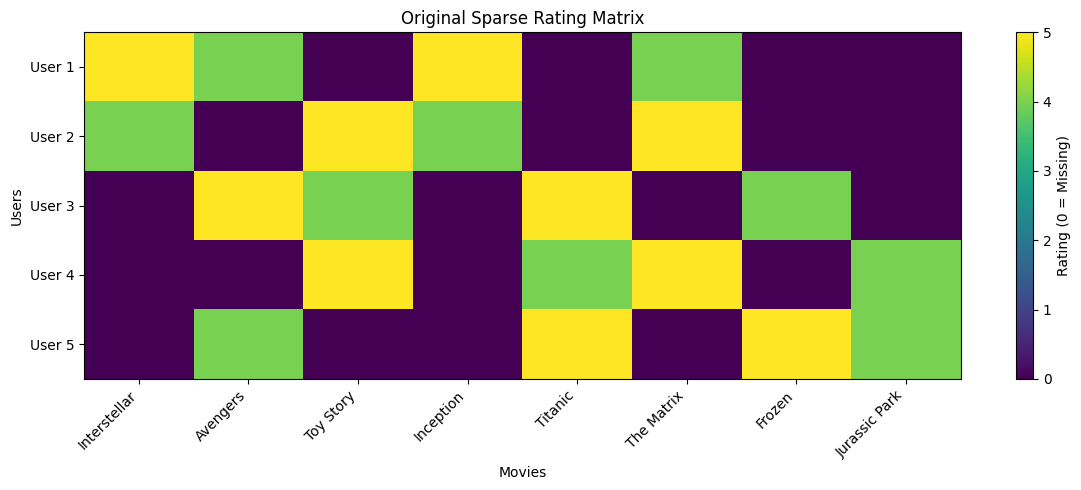

In [13]:
plt.figure(figsize=(12, 5))

plt.imshow(
    R,
    aspect="auto"
)

plt.colorbar(
    label="Rating (0 = Missing)"
)

plt.xticks(
    range(len(movies)),
    movies,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(users)),
    users
)

plt.title("Original Sparse Rating Matrix")

plt.xlabel("Movies")
plt.ylabel("Users")

plt.tight_layout()
plt.show()

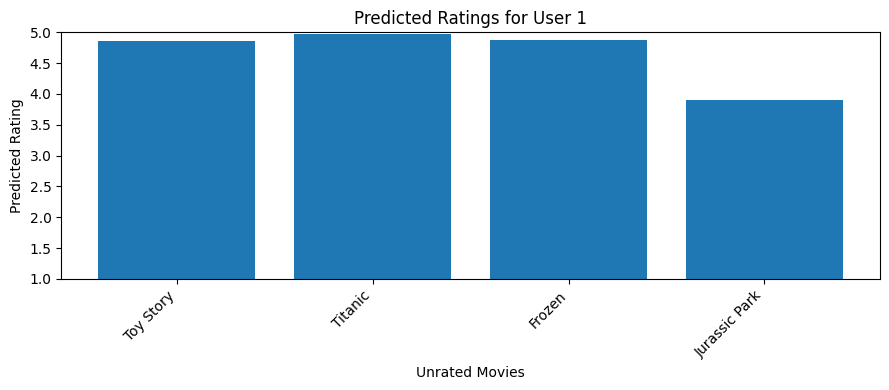

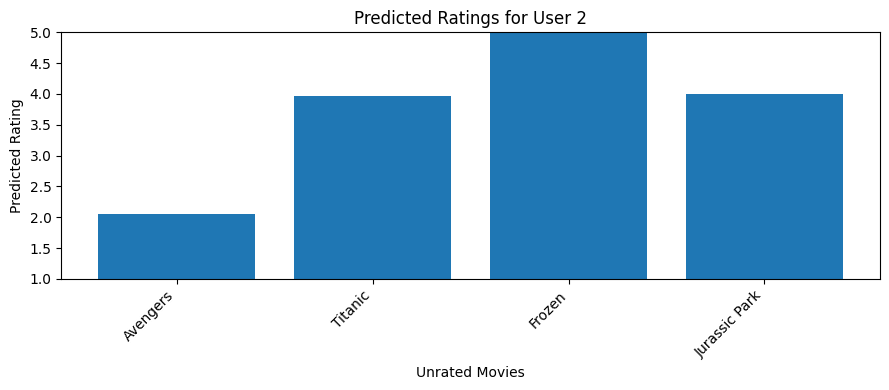

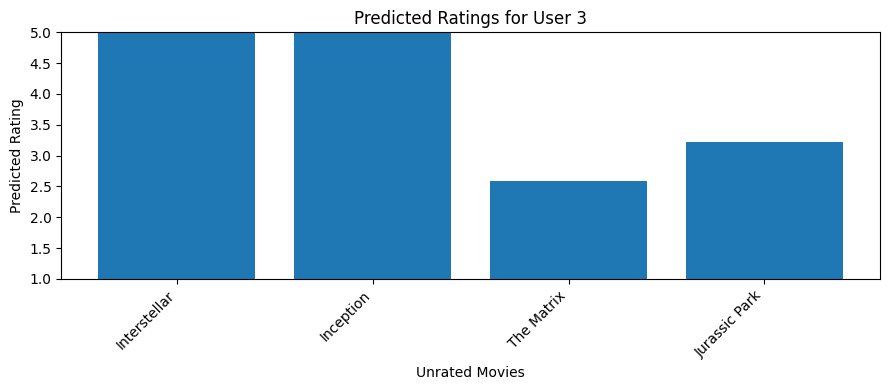

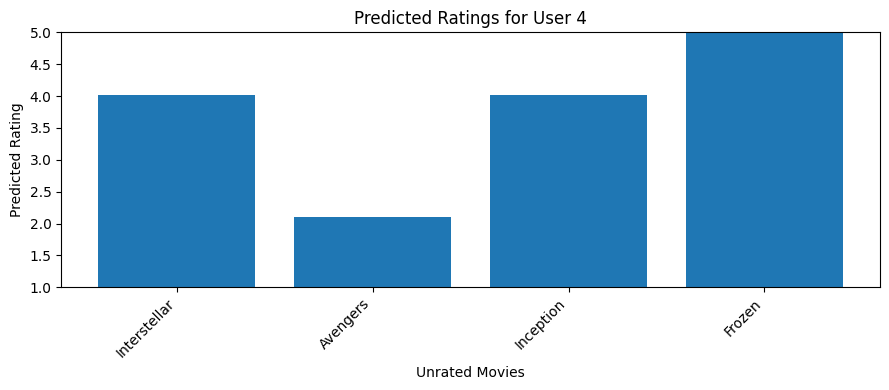

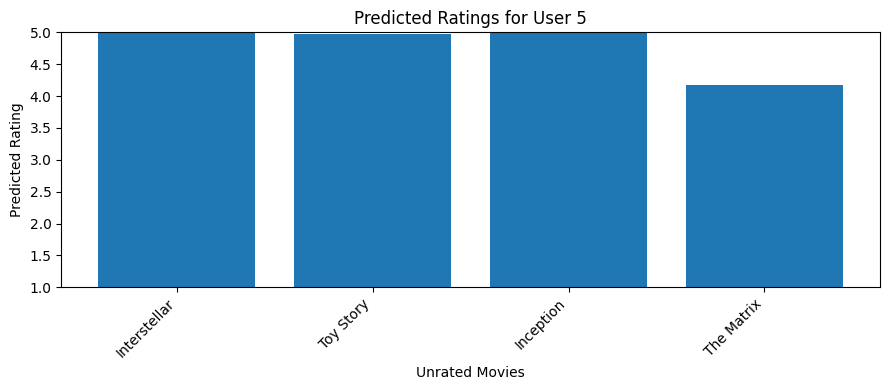

In [15]:
for i, user in enumerate(users):

    unrated_indices = np.where(R[i] == 0)[0]

    movie_names = [
        movies[j]
        for j in unrated_indices
    ]

    values = completed_R[
        i,
        unrated_indices
    ]

    plt.figure(figsize=(9, 4))

    plt.bar(
        movie_names,
        values
    )

    plt.ylim(1, 5)

    plt.xlabel("Unrated Movies")
    plt.ylabel("Predicted Rating")

    plt.title(
        f"Predicted Ratings for {user}"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

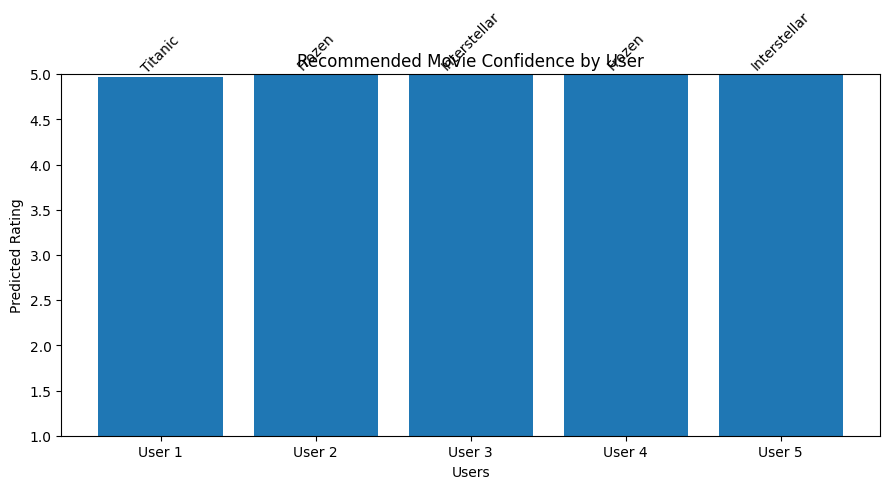

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    recommendation_table["User"],
    recommendation_table["Predicted Rating"]
)

plt.ylim(1, 5)

plt.xlabel("Users")
plt.ylabel("Predicted Rating")

plt.title(
    "Recommended Movie Confidence by User"
)

for i, row in recommendation_table.iterrows():

    plt.text(
        i,
        row["Predicted Rating"] + 0.05,
        row["Recommended Movie"],
        ha="center",
        rotation=45
    )

plt.tight_layout()
plt.show()